##Installation des bibliothèques

In [ ]:
# ================================
# INSTALLATION
# Nouvelles bibliothèques du projet
# ================================

# imbalanced-learn → contient SMOTE
# xgboost         → algorithme XGBoost
!pip install imbalanced-learn xgboost --quiet

print("✅ Installation terminée")

✅ Installation terminée


####Inmporter toutes les biblio

In [ ]:
# ================================
# IMPORTS
# ================================

# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             precision_recall_curve,
                             average_precision_score,
                             roc_auc_score)

# Gestion du déséquilibre
from imblearn.over_sampling import SMOTE

# XGBoost
from xgboost import XGBClassifier

# Utilitaires
import warnings
warnings.filterwarnings('ignore')
import time

print("✅ Toutes les bibliothèques importées")

✅ Toutes les bibliothèques importées


####Charger les données

In [ ]:
# ================================
# CHARGEMENT DES DONNÉES
# ================================

url = "https://raw.githubusercontent.com/mlflow/mlflow/master/tests/datasets/winequality-red.csv"

# Ce dataset nécessite Kaggle normalement
# On utilise une copie publique disponible directement
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

print("✅ Dataset chargé !")
print(f"📐 Dimensions     : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"💾 Taille mémoire : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\n📋 Colonnes :")
print(df.columns.tolist())
print(f"\n📊 Aperçu :")
df.head(3)

✅ Dataset chargé !
📐 Dimensions     : 284,807 lignes × 31 colonnes
💾 Taille mémoire : 67.4 MB

📋 Colonnes :
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

📊 Aperçu :


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


#### Premier diagnostic

🔍 DIAGNOSTIC DU DÉSÉQUILIBRE

📊 Transactions normales  : 284,315  (99.83%)
🚨 Transactions fraudeuses:     492  (0.17%)
📐 Total                  : 284,807

⚠️  Ratio déséquilibre : 1 fraude / 577 transactions normales


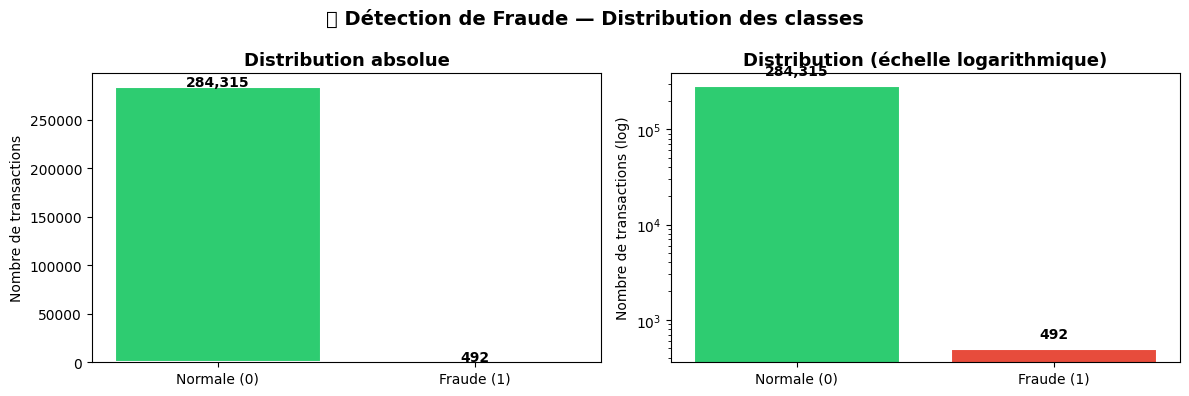


💡 L'échelle logarithmique permet de visualiser
   les deux classes malgré leur différence énorme.


In [ ]:
# ================================
# DIAGNOSTIC IMMÉDIAT
# ================================

fraudes   = df['Class'].sum()
normales  = len(df) - fraudes
total     = len(df)
pct_fraude = fraudes / total * 100

print("=" * 55)
print("🔍 DIAGNOSTIC DU DÉSÉQUILIBRE")
print("=" * 55)

print(f"\n📊 Transactions normales  : {normales:>7,}  ({100-pct_fraude:.2f}%)")
print(f"🚨 Transactions fraudeuses: {fraudes:>7,}  ({pct_fraude:.2f}%)")
print(f"📐 Total                  : {total:>7,}")

print(f"\n⚠️  Ratio déséquilibre : 1 fraude / {int(normales/fraudes)} transactions normales")

# Visualisation immédiate
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Normale (0)', 'Fraude (1)'],
            [normales, fraudes],
            color=['#2ecc71', '#e74c3c'],
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution absolue', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Nombre de transactions')
for i, v in enumerate([normales, fraudes]):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Log scale pour voir les deux barres
axes[1].bar(['Normale (0)', 'Fraude (1)'],
            [normales, fraudes],
            color=['#2ecc71', '#e74c3c'],
            edgecolor='white', linewidth=1.5)
axes[1].set_yscale('log')
axes[1].set_title('Distribution (échelle logarithmique)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Nombre de transactions (log)')
axes[1].text(0, normales * 1.3, f'{normales:,}', ha='center', fontweight='bold')
axes[1].text(1, fraudes * 1.3, f'{fraudes:,}', ha='center', fontweight='bold')

plt.suptitle('🏦 Détection de Fraude — Distribution des classes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distribution_fraude.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 L'échelle logarithmique permet de visualiser")
print("   les deux classes malgré leur différence énorme.")

##EDA

Ce qu'on cherhce à comprendre :

Question 1 : Les fraudes ont-elles des montants différents ?

Question 2 : Les fraudes surviennent-elles à certaines heures ?

Question 3 : Quelles variables V1-V28 distinguent le mieux
             une fraude d'une transaction normale ?

###1. Vue générale du dataset

In [ ]:
# ================================
# EDA — Vue générale
# ================================

print("=" * 55)
print("📋 INFORMATIONS GÉNÉRALES")
print("=" * 55)

print(f"\n📐 Dimensions      : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"❓ Valeurs manquantes : {df.isnull().sum().sum()}")
print(f"\n📊 Types de colonnes :")
print(df.dtypes.value_counts())

print(f"\n📈 Statistiques — Montants des transactions :")
print(f"   Montant moyen   : {df['Amount'].mean():.2f} €")
print(f"   Montant médian  : {df['Amount'].median():.2f} €")
print(f"   Montant maximum : {df['Amount'].max():.2f} €")
print(f"   Montant minimum : {df['Amount'].min():.2f} €")

print(f"\n⏱️  Durée couverte par le dataset :")
print(f"   De        : {df['Time'].min():.0f} secondes")
print(f"   À         : {df['Time'].max():.0f} secondes")
print(f"   Soit      : {df['Time'].max()/3600:.1f} heures ≈ 2 jours")

📋 INFORMATIONS GÉNÉRALES

📐 Dimensions      : 284,807 lignes × 31 colonnes
❓ Valeurs manquantes : 0

📊 Types de colonnes :
float64    30
int64       1
Name: count, dtype: int64

📈 Statistiques — Montants des transactions :
   Montant moyen   : 88.35 €
   Montant médian  : 22.00 €
   Montant maximum : 25691.16 €
   Montant minimum : 0.00 €

⏱️  Durée couverte par le dataset :
   De        : 0 secondes
   À         : 172792 secondes
   Soit      : 48.0 heures ≈ 2 jours


### 2. Analyse des montants

💰 STATISTIQUES DES MONTANTS

                          Normale       Fraude
---------------------------------------------
Moyenne                     88.29       122.21
Médiane                     22.00         9.25
Maximum                  25691.16      2125.87
Minimum                      0.00         0.00


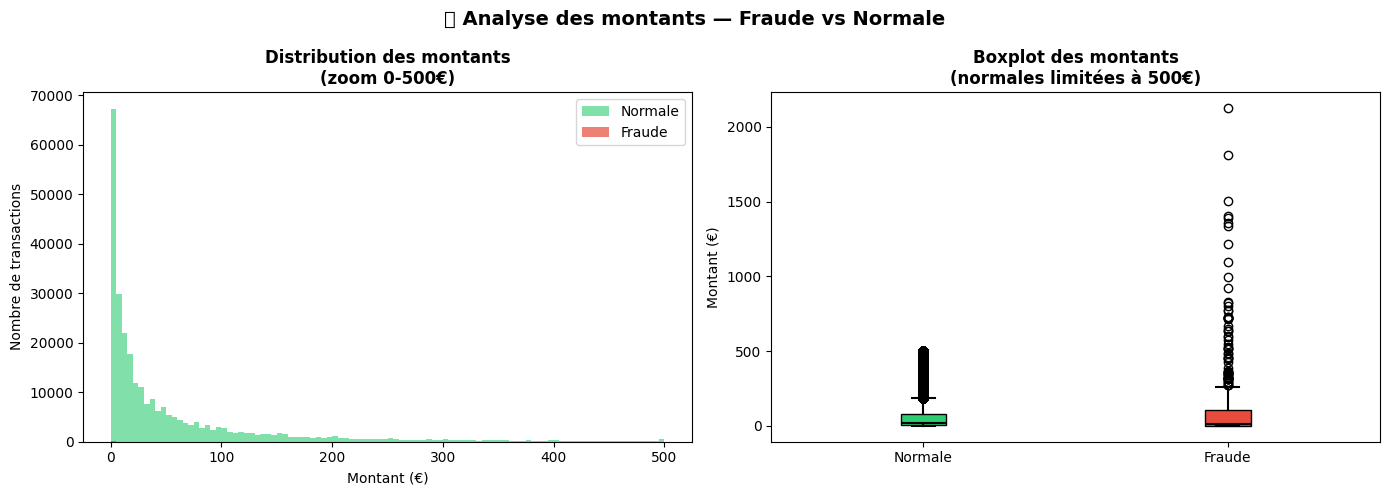

In [ ]:
# ================================
# EDA — Analyse des montants
# ================================

fraudes_df  = df[df['Class'] == 1]   # toutes les fraudes
normales_df = df[df['Class'] == 0]   # toutes les normales

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Graphique 1 : Distribution des montants ---
axes[0].hist(normales_df['Amount'],
             bins=100, alpha=0.6,
             color='#2ecc71', label='Normale',
             range=(0, 500))

axes[0].hist(fraudes_df['Amount'],
             bins=100, alpha=0.7,
             color='#e74c3c', label='Fraude',
             range=(0, 500))

axes[0].set_title('Distribution des montants\n(zoom 0-500€)',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Montant (€)')
axes[0].set_ylabel('Nombre de transactions')
axes[0].legend()

# --- Graphique 2 : Boxplot comparatif ---
data_boxplot = [normales_df['Amount'].clip(upper=500),
                fraudes_df['Amount']]

bp = axes[1].boxplot(data_boxplot,
                     labels=['Normale', 'Fraude'],
                     patch_artist=True,
                     notch=False)

bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')

for element in ['whiskers', 'caps', 'medians']:
    for item in bp[element]:
        item.set_color('black')
        item.set_linewidth(1.5)

axes[1].set_title('Boxplot des montants\n(normales limitées à 500€)',
                  fontweight='bold', fontsize=12)
axes[1].set_ylabel('Montant (€)')

# Annotations statistiques
stats_fraude  = fraudes_df['Amount'].describe()
stats_normale = normales_df['Amount'].describe()

print("💰 STATISTIQUES DES MONTANTS")
print(f"\n{'':20} {'Normale':>12} {'Fraude':>12}")
print("-" * 45)
print(f"{'Moyenne':20} {stats_normale['mean']:>12.2f} {stats_fraude['mean']:>12.2f}")
print(f"{'Médiane':20} {stats_normale['50%']:>12.2f} {stats_fraude['50%']:>12.2f}")
print(f"{'Maximum':20} {stats_normale['max']:>12.2f} {stats_fraude['max']:>12.2f}")
print(f"{'Minimum':20} {stats_normale['min']:>12.2f} {stats_fraude['min']:>12.2f}")

plt.suptitle('💰 Analyse des montants — Fraude vs Normale',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('analyse_montants.png', dpi=150, bbox_inches='tight')
plt.show()

###3. Analyse temporelle

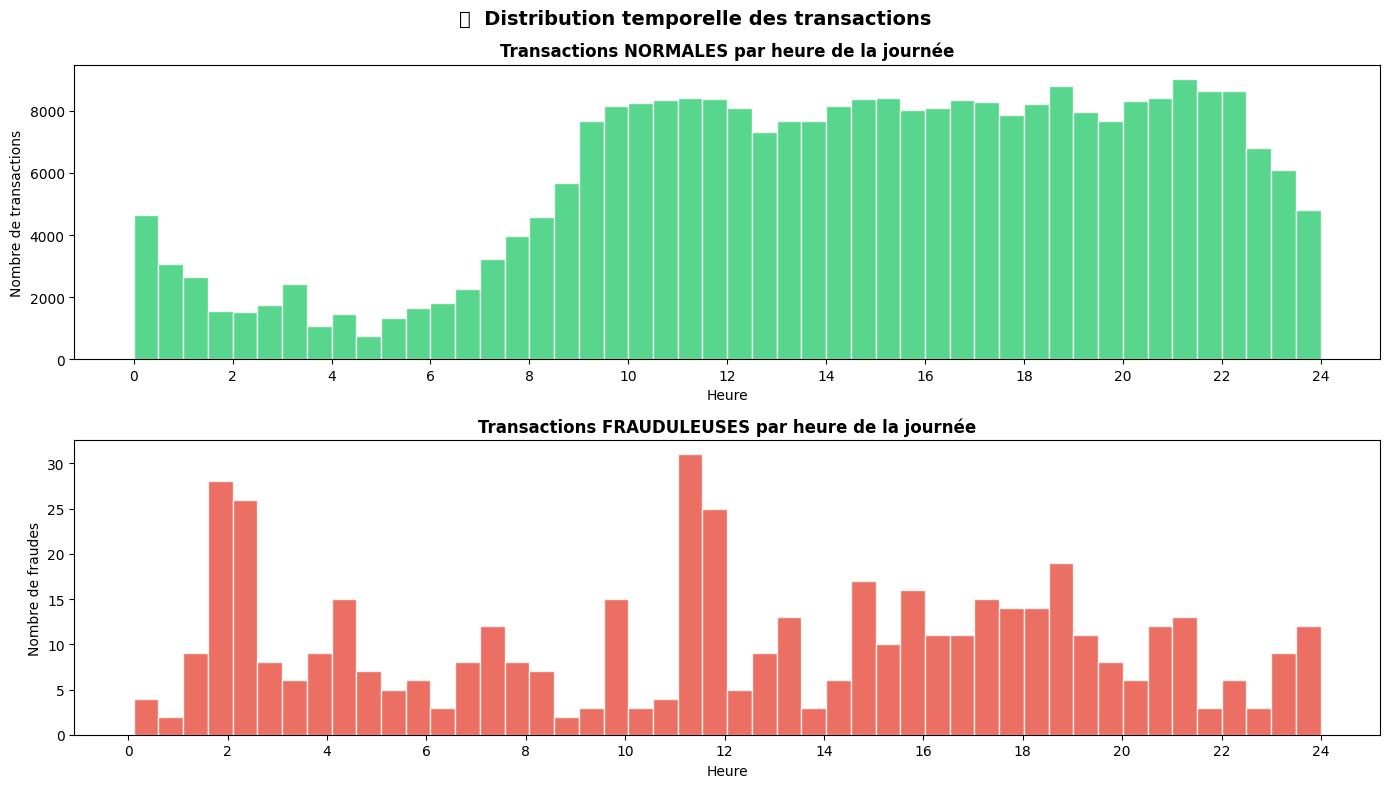

⏱️  ANALYSE TEMPORELLE

Fraudes — heure moyenne    : 12.1h
Fraudes — heure médiane    : 12.1h
Normales — heure moyenne   : 14.5h
Normales — heure médiane   : 15.0h


In [ ]:
# ================================
# EDA — Analyse temporelle
# ================================

# Convertir les secondes en heures (plus lisible)
df['Hour'] = (df['Time'] / 3600) % 24
# % 24 → ramène les heures dans le cycle 0-24
# Ex: heure 25 → heure 1 (du lendemain)

fraudes_df  = df[df['Class'] == 1]
normales_df = df[df['Class'] == 0]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# --- Graphique 1 : Transactions normales par heure ---
axes[0].hist(normales_df['Hour'], bins=48,
             color='#2ecc71', alpha=0.8, edgecolor='white')
axes[0].set_title('Transactions NORMALES par heure de la journée',
                  fontweight='bold', fontsize=12)
axes[0].set_ylabel('Nombre de transactions')
axes[0].set_xlabel('Heure')
axes[0].set_xticks(range(0, 25, 2))

# --- Graphique 2 : Fraudes par heure ---
axes[1].hist(fraudes_df['Hour'], bins=48,
             color='#e74c3c', alpha=0.8, edgecolor='white')
axes[1].set_title('Transactions FRAUDULEUSES par heure de la journée',
                  fontweight='bold', fontsize=12)
axes[1].set_ylabel('Nombre de fraudes')
axes[1].set_xlabel('Heure')
axes[1].set_xticks(range(0, 25, 2))

plt.suptitle('⏱️  Distribution temporelle des transactions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('analyse_temporelle.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats temporelles
print("⏱️  ANALYSE TEMPORELLE")
print(f"\nFraudes — heure moyenne    : {fraudes_df['Hour'].mean():.1f}h")
print(f"Fraudes — heure médiane    : {fraudes_df['Hour'].median():.1f}h")
print(f"Normales — heure moyenne   : {normales_df['Hour'].mean():.1f}h")
print(f"Normales — heure médiane   : {normales_df['Hour'].median():.1f}h")

###4. Quelles variables V distinguent les fraudes

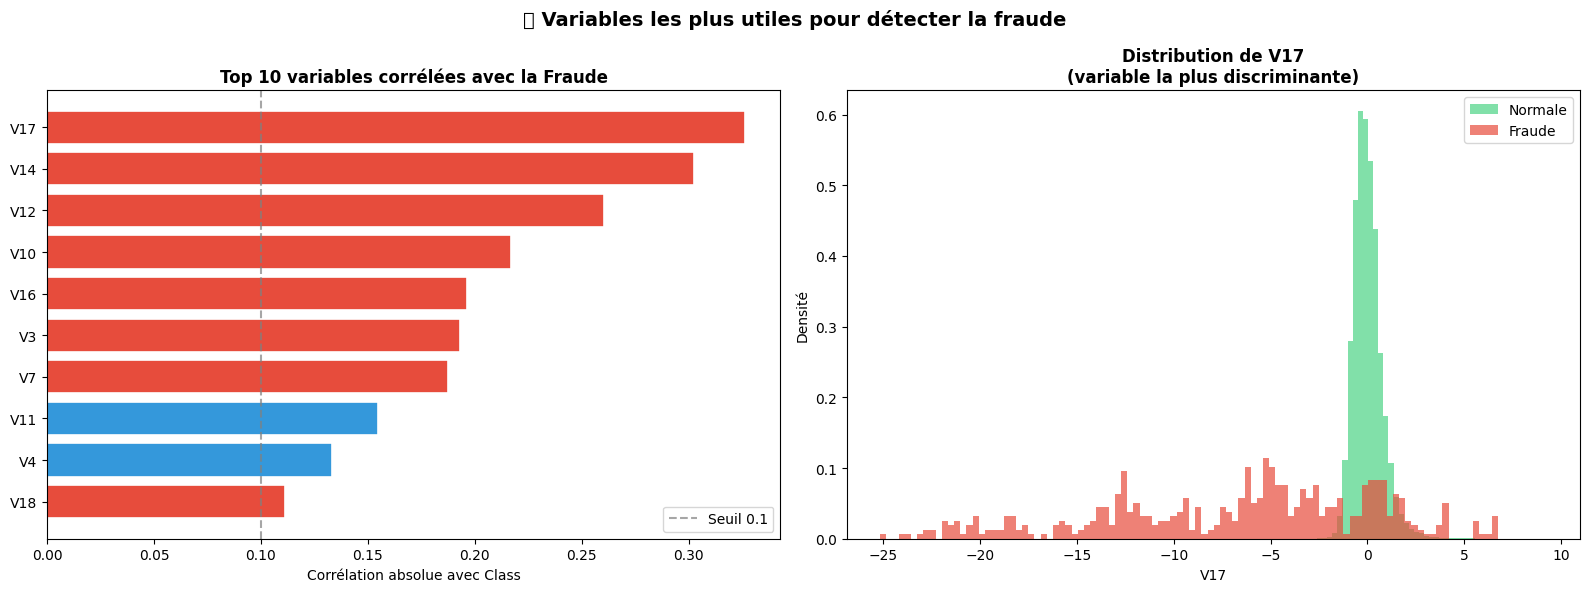

🔍 TOP 10 VARIABLES CORRÉLÉES AVEC LA FRAUDE :

Variable       Corrélation    Direction
----------------------------------------
V17                -0.3265   🔴 négative
V14                -0.3025   🔴 négative
V12                -0.2606   🔴 négative
V10                -0.2169   🔴 négative
V16                -0.1965   🔴 négative
V3                 -0.1930   🔴 négative
V7                 -0.1873   🔴 négative
V11                 0.1549   🔵 positive
V4                  0.1334   🔵 positive
V18                -0.1115   🔴 négative


In [ ]:
# ================================
# EDA — Variables V les plus discriminantes
# ================================

# Calculer la corrélation de chaque variable avec Class
correlations = df.corr()['Class'].drop('Class')
correlations_abs = correlations.abs().sort_values(ascending=False)

# Garder le top 10
top10 = correlations_abs.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique 1 : Corrélations ---
colors = ['#e74c3c' if correlations[col] < 0
          else '#3498db'
          for col in top10.index]

axes[0].barh(top10.index[::-1], top10.values[::-1],
             color=colors[::-1], edgecolor='white', linewidth=1.2)
axes[0].set_title('Top 10 variables corrélées avec la Fraude',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Corrélation absolue avec Class')
axes[0].axvline(x=0.1, color='gray', linestyle='--',
                alpha=0.7, label='Seuil 0.1')
axes[0].legend()

# --- Graphique 2 : Distribution de V14 (meilleure variable) ---
best_var = top10.index[0]

axes[1].hist(normales_df[best_var], bins=100,
             alpha=0.6, color='#2ecc71',
             label='Normale', density=True)
axes[1].hist(fraudes_df[best_var], bins=100,
             alpha=0.7, color='#e74c3c',
             label='Fraude', density=True)
axes[1].set_title(f'Distribution de {best_var}\n(variable la plus discriminante)',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel(best_var)
axes[1].set_ylabel('Densité')
axes[1].legend()

plt.suptitle('🔍 Variables les plus utiles pour détecter la fraude',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('variables_discriminantes.png', dpi=150, bbox_inches='tight')
plt.show()

print("🔍 TOP 10 VARIABLES CORRÉLÉES AVEC LA FRAUDE :")
print(f"\n{'Variable':10} {'Corrélation':>15} {'Direction':>12}")
print("-" * 40)
for col in top10.index:
    direction = "🔴 négative" if correlations[col] < 0 else "🔵 positive"
    print(f"{col:10} {correlations[col]:>15.4f} {direction:>12}")

### Feature Engineering

In [ ]:
# ================================
# FEATURE ENGINEERING
# ================================

print("🔧 Création de nouvelles features...")
print(f"Dimensions AVANT : {df.shape}")

# --- Feature 1 : Heure de la journée ---
# Déjà créée dans l'EDA, on la garde
df['Hour'] = (df['Time'] / 3600) % 24

# --- Feature 2 : Période de la journée ---
# Basé sur notre observation : fraudes pic à 2h du matin
def get_periode(hour):
    if 0 <= hour < 6:
        return 0    # Nuit (risque élevé)
    elif 6 <= hour < 12:
        return 1    # Matin
    elif 12 <= hour < 18:
        return 2    # Après-midi
    else:
        return 3    # Soir

df['Period'] = df['Hour'].apply(get_periode)

# --- Feature 3 : Log du montant ---
# Pourquoi ? Amount varie de 0 à 25691€
# Cette dispersion énorme perturbe les modèles ML
# Le log "compresse" les grandes valeurs
# np.log1p = log(1 + x) → évite log(0) qui est indéfini
df['Amount_log'] = np.log1p(df['Amount'])

# --- Feature 4 : Petit montant ? (test de carte) ---
# Notre EDA : médiane fraude = 9.25€
# Les fraudeurs testent souvent avec < 10€
df['is_small_amount'] = (df['Amount'] < 10).astype(int)

# --- Feature 5 : Heure à risque ? ---
# Notre EDA : pic de fraudes entre 1h et 3h du matin
df['is_night_fraud_peak'] = (
    (df['Hour'] >= 1) & (df['Hour'] <= 3)
).astype(int)

# --- Feature 6 : Montant élevé ? ---
# Les fraudeurs font parfois de gros achats après test
# Seuil : au-dessus du 95e percentile des normales
seuil_95 = df[df['Class']==0]['Amount'].quantile(0.95)
df['is_high_amount'] = (df['Amount'] > seuil_95).astype(int)

print(f"Dimensions APRÈS  : {df.shape}")
print(f"\n✅ Features créées :")
print(f"   Hour                → heure de la journée (0-24)")
print(f"   Period              → période (nuit/matin/aprèsmidi/soir)")
print(f"   Amount_log          → log du montant")
print(f"   is_small_amount     → montant < 10€ ? (1=oui, 0=non)")
print(f"   is_night_fraud_peak → entre 1h et 3h ? (1=oui, 0=non)")
print(f"   is_high_amount      → montant > {seuil_95:.2f}€ ? (1=oui, 0=non)")

# Vérification : les features nocturnes capturent-elles des fraudes ?
fraudes_nuit = df[(df['is_night_fraud_peak']==1) & (df['Class']==1)]
print(f"\n📊 Validation :")
print(f"   Fraudes entre 1h-3h : {len(fraudes_nuit)} / {df['Class'].sum()}")
print(f"   Soit {len(fraudes_nuit)/df['Class'].sum()*100:.1f}% de toutes les fraudes")
print(f"   Seuil montant élevé : {seuil_95:.2f}€")

🔧 Création de nouvelles features...
Dimensions AVANT : (284807, 32)
Dimensions APRÈS  : (284807, 37)

✅ Features créées :
   Hour                → heure de la journée (0-24)
   Period              → période (nuit/matin/aprèsmidi/soir)
   Amount_log          → log du montant
   is_small_amount     → montant < 10€ ? (1=oui, 0=non)
   is_night_fraud_peak → entre 1h et 3h ? (1=oui, 0=non)
   is_high_amount      → montant > 364.41€ ? (1=oui, 0=non)

📊 Validation :
   Fraudes entre 1h-3h : 67 / 492
   Soit 13.6% de toutes les fraudes
   Seuil montant élevé : 364.41€


##Gestion du déséquilibre SMOTE

### 1. Préparation avant SMOTE

In [ ]:
# ================================
# PRÉPARATION — Split avant SMOTE
# ================================

# RÈGLE IMPORTANTE :
# On applique SMOTE UNIQUEMENT sur le train
# JAMAIS sur le test → le test doit rester réel

# Supprimer Time (remplacé par Hour et Period)
df_model = df.drop(columns=['Time'])

# Séparer X et y
X = df_model.drop(columns=['Class'])
y = df_model['Class']

print(f"✅ Features (X) : {X.shape}")
print(f"✅ Cible (y)    : {y.shape}")
print(f"\nDistribution avant split :")
print(f"   Normales : {(y==0).sum():,}")
print(f"   Fraudes  : {(y==1).sum():,}")

# Split train/test AVANT SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✅ Split effectué :")
print(f"   Train : {X_train.shape[0]:,} transactions")
print(f"   Test  : {X_test.shape[0]:,} transactions")
print(f"\n   Fraudes dans train : {y_train.sum()}")
print(f"   Fraudes dans test  : {y_test.sum()}")

✅ Features (X) : (284807, 35)
✅ Cible (y)    : (284807,)

Distribution avant split :
   Normales : 284,315
   Fraudes  : 492

✅ Split effectué :
   Train : 227,845 transactions
   Test  : 56,962 transactions

   Fraudes dans train : 394
   Fraudes dans test  : 98


###2. Normalisation

In [ ]:
# ================================
# NORMALISATION
# ================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Normalisation effectuée")
print("   fit_transform sur train uniquement")
print("   transform seulement sur test (pas de data leakage)")

✅ Normalisation effectuée
   fit_transform sur train uniquement
   transform seulement sur test (pas de data leakage)


###3. Appliquer SMOTE

In [ ]:
# ================================
# SMOTE — Rééquilibrage
# ================================

from imblearn.over_sampling import SMOTE

print("⏳ Application de SMOTE...")
print(f"   AVANT — Normales: {(y_train==0).sum():,} | Fraudes: {y_train.sum()}")

smote = SMOTE(
    sampling_strategy=0.1,  # fraudes = 10% des normales après SMOTE
    random_state=42,
    k_neighbors=5           # utilise 5 voisins pour créer chaque exemple
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled, y_train
)

print(f"   APRÈS — Normales: {(y_train_smote==0).sum():,} | Fraudes: {y_train_smote.sum():,}")
print(f"\n✅ SMOTE terminé !")
print(f"   Fraudes créées : {y_train_smote.sum() - y_train.sum():,} exemples synthétiques")
print(f"   Nouveau ratio  : 1 fraude / {int((y_train_smote==0).sum()/y_train_smote.sum())} normales")

⏳ Application de SMOTE...
   AVANT — Normales: 227,451 | Fraudes: 394
   APRÈS — Normales: 227,451 | Fraudes: 22,745

✅ SMOTE terminé !
   Fraudes créées : 22,351 exemples synthétiques
   Nouveau ratio  : 1 fraude / 10 normales


###4. Effet de SMOTE

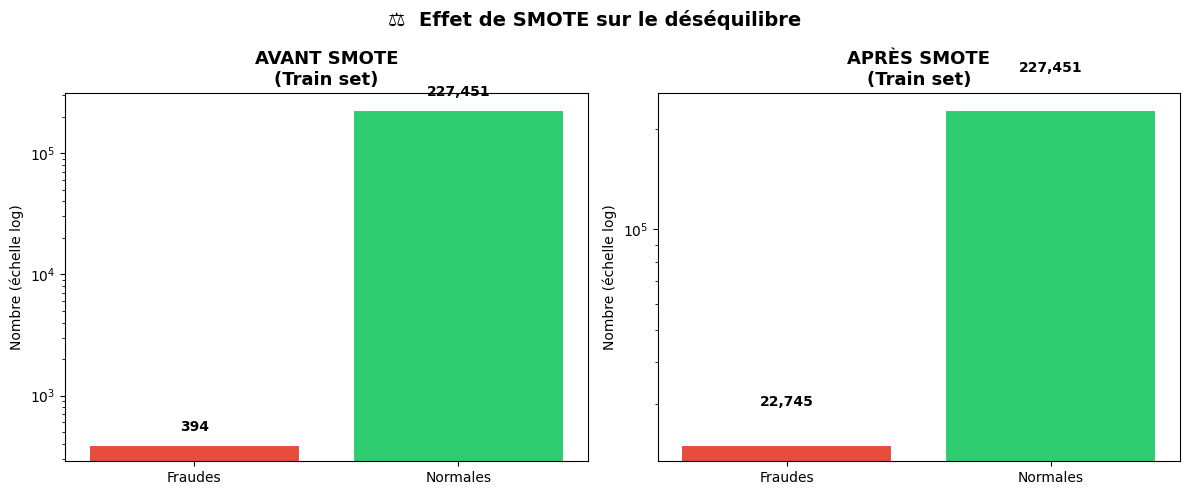


💡 RAPPEL IMPORTANT :
   SMOTE appliqué UNIQUEMENT sur X_train_scaled
   X_test_scaled reste intact → données 100% réelles
   Le test doit toujours refléter la réalité du terrain


In [ ]:
# ================================
# VISUALISATION — Avant/Après SMOTE
# ================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# AVANT SMOTE
avant = [y_train.sum(), (y_train==0).sum()]
axes[0].bar(['Fraudes', 'Normales'], avant,
            color=['#e74c3c', '#2ecc71'],
            edgecolor='white', linewidth=1.5)
axes[0].set_yscale('log')
axes[0].set_title('AVANT SMOTE\n(Train set)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Nombre (échelle log)')
for i, v in enumerate(avant):
    axes[0].text(i, v*1.3, f'{v:,}', ha='center', fontweight='bold')

# APRÈS SMOTE
apres = [y_train_smote.sum(), (y_train_smote==0).sum()]
axes[1].bar(['Fraudes', 'Normales'], apres,
            color=['#e74c3c', '#2ecc71'],
            edgecolor='white', linewidth=1.5)
axes[1].set_yscale('log')
axes[1].set_title('APRÈS SMOTE\n(Train set)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Nombre (échelle log)')
for i, v in enumerate(apres):
    axes[1].text(i, v*1.3, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('⚖️  Effet de SMOTE sur le déséquilibre',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_effet.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 RAPPEL IMPORTANT :")
print("   SMOTE appliqué UNIQUEMENT sur X_train_scaled")
print("   X_test_scaled reste intact → données 100% réelles")
print("   Le test doit toujours refléter la réalité du terrain")

##Entrainement


### Entrainer Random Forest

In [ ]:
# ================================
# MODÈLE 1 — Random Forest
# ================================
import time

print("=" * 50)
print("🌲 RANDOM FOREST")
print("=" * 50)

debut = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1           # utilise tous les cœurs du CPU
)

rf_model.fit(X_train_smote, y_train_smote)

duree_rf = time.time() - debut

print(f"✅ Entraîné en {duree_rf:.1f} secondes")
print(f"   Arbres         : {rf_model.n_estimators}")
print(f"   Profondeur max : {rf_model.max_depth}")
print(f"   CPU utilisés   : tous (n_jobs=-1)")

🌲 RANDOM FOREST
✅ Entraîné en 131.9 secondes
   Arbres         : 100
   Profondeur max : 15
   CPU utilisés   : tous (n_jobs=-1)


###2. Entrainer XGBOOST

In [ ]:
# ================================
# MODÈLE 2 — XGBoost
# ================================

print("=" * 50)
print("⚡ XGBOOST")
print("=" * 50)

debut = time.time()

# Calculer le ratio pour scale_pos_weight
# (alternative à SMOTE pour XGBoost)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='aucpr',
    verbosity=0
)

xgb_model.fit(X_train_smote, y_train_smote)

duree_xgb = time.time() - debut

print(f"✅ Entraîné en {duree_xgb:.1f} secondes")
print(f"   Arbres          : {xgb_model.n_estimators}")
print(f"   Profondeur max  : {xgb_model.max_depth}")
print(f"   Learning rate   : {xgb_model.learning_rate}")
print(f"   Scale pos weight: {ratio:.1f}")

⚡ XGBOOST
✅ Entraîné en 14.8 secondes
   Arbres          : 200
   Profondeur max  : 6
   Learning rate   : 0.1
   Scale pos weight: 577.3


###3. Prédiction des 2 modèles

In [ ]:
# ================================
# PRÉDICTIONS
# ================================

# Random Forest
rf_pred       = rf_model.predict(X_test_scaled)
rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# XGBoost
xgb_pred       = xgb_model.predict(X_test_scaled)
xgb_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("✅ Prédictions effectuées sur le test set")
print(f"\n{'':30} {'Random Forest':>15} {'XGBoost':>10}")
print("-" * 58)
print(f"{'Fraudes prédites':30} {rf_pred.sum():>15} {xgb_pred.sum():>10}")
print(f"{'Vraies fraudes (y_test)':30} {y_test.sum():>15} {y_test.sum():>10}")

✅ Prédictions effectuées sur le test set

                                 Random Forest    XGBoost
----------------------------------------------------------
Fraudes prédites                           114        147
Vraies fraudes (y_test)                     98         98


###4. Evaluation et comparaison

In [ ]:
# ================================
# ÉVALUATION COMPLÈTE
# ================================

from sklearn.metrics import (average_precision_score,
                             precision_recall_curve,
                             roc_auc_score,
                             confusion_matrix,
                             classification_report)

# Calcul des métriques
def evaluer_modele(nom, y_true, y_pred, y_proba):
    """
    Fonction qui calcule toutes les métriques
    pour un modèle donné
    """
    cm      = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    recall    = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    roc_auc   = roc_auc_score(y_true, y_proba)
    pr_auc    = average_precision_score(y_true, y_proba)

    print(f"\n{'='*50}")
    print(f"  {nom}")
    print(f"{'='*50}")
    print(f"  TP (fraudes détectées)    : {tp:>6}")
    print(f"  FN (fraudes manquées)     : {fn:>6}  ← minimiser")
    print(f"  FP (fausses alertes)      : {fp:>6}")
    print(f"  TN (normales correctes)   : {tn:>6}")
    print(f"  {'─'*35}")
    print(f"  Recall (fraudes détectées): {recall*100:>6.1f}%  ← priorité")
    print(f"  Precision                 : {precision*100:>6.1f}%")
    print(f"  F1-Score                  : {f1*100:>6.1f}%")
    print(f"  ROC-AUC                   : {roc_auc*100:>6.1f}%")
    print(f"  PR-AUC                    : {pr_auc*100:>6.1f}%  ← métrique clé")

    return {
        'nom': nom, 'tp': tp, 'fn': fn, 'fp': fp, 'tn': tn,
        'recall': recall, 'precision': precision,
        'f1': f1, 'roc_auc': roc_auc, 'pr_auc': pr_auc
    }

# Évaluer les deux modèles
resultats_rf  = evaluer_modele(
    "🌲 RANDOM FOREST",
    y_test, rf_pred, rf_pred_proba
)
resultats_xgb = evaluer_modele(
    "⚡ XGBOOST",
    y_test, xgb_pred, xgb_pred_proba
)


  🌲 RANDOM FOREST
  TP (fraudes détectées)    :     82
  FN (fraudes manquées)     :     16  ← minimiser
  FP (fausses alertes)      :     32
  TN (normales correctes)   :  56832
  ───────────────────────────────────
  Recall (fraudes détectées):   83.7%  ← priorité
  Precision                 :   71.9%
  F1-Score                  :   77.4%
  ROC-AUC                   :   98.4%
  PR-AUC                    :   85.0%  ← métrique clé

  ⚡ XGBOOST
  TP (fraudes détectées)    :     87
  FN (fraudes manquées)     :     11  ← minimiser
  FP (fausses alertes)      :     60
  TN (normales correctes)   :  56804
  ───────────────────────────────────
  Recall (fraudes détectées):   88.8%  ← priorité
  Precision                 :   59.2%
  F1-Score                  :   71.0%
  ROC-AUC                   :   98.5%
  PR-AUC                    :   87.3%  ← métrique clé


###5. Graphique de comparaison finale

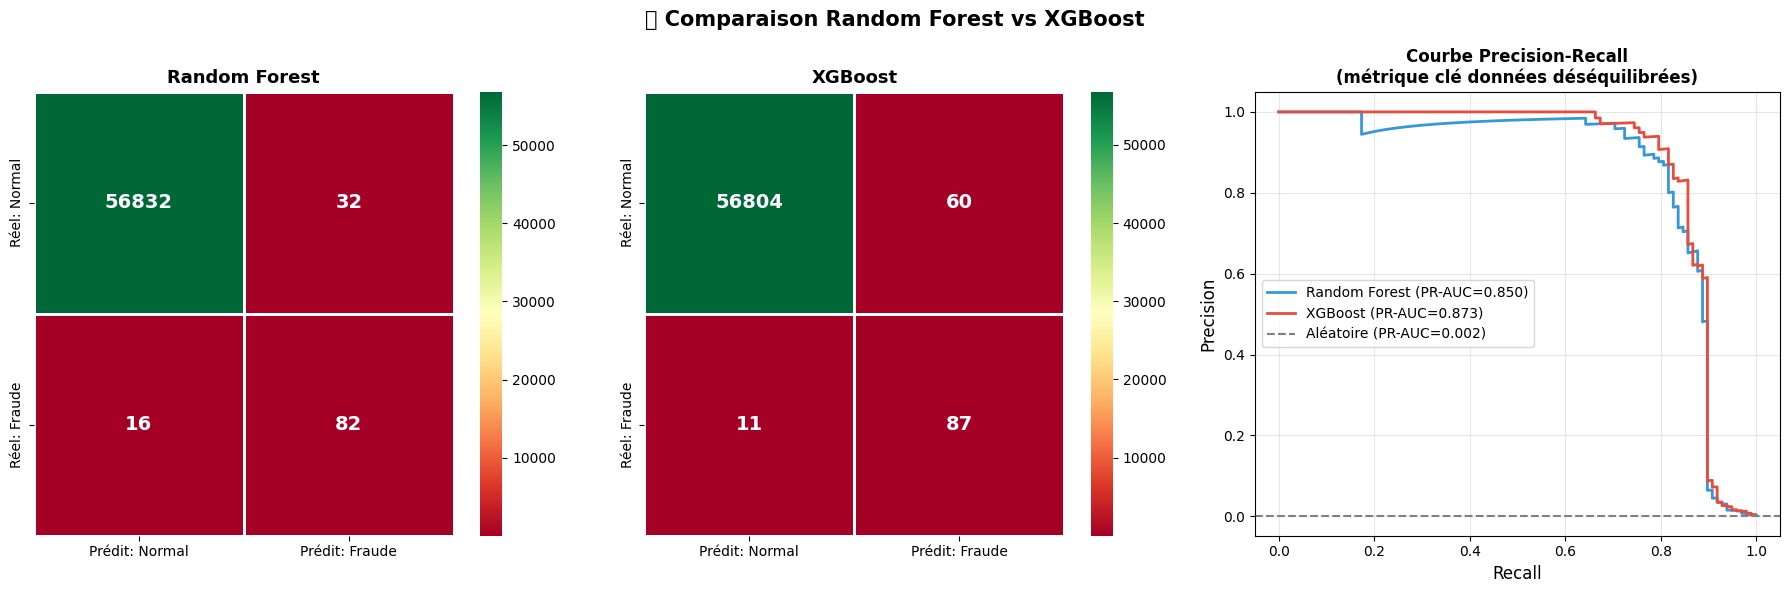

In [ ]:
# ================================
# COMPARAISON VISUELLE
# ================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Graphique 1 : Matrices de confusion côte à côte ---
for i, (modele, pred, nom) in enumerate([
    (rf_model,  rf_pred,  "Random Forest"),
    (xgb_model, xgb_pred, "XGBoost")
]):
    if i == 0:
        ax = axes[0]
    else:
        ax = axes[1]

    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
                xticklabels=['Prédit: Normal', 'Prédit: Fraude'],
                yticklabels=['Réel: Normal', 'Réel: Fraude'],
                ax=ax, linewidths=2, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'{nom}', fontsize=13, fontweight='bold')

# --- Graphique 2 : Courbes PR (Precision-Recall) ---
for y_proba, nom, couleur in [
    (rf_pred_proba,  'Random Forest', '#3498db'),
    (xgb_pred_proba, 'XGBoost',       '#e74c3c')
]:
    precision_curve, recall_curve, _ = precision_recall_curve(
        y_test, y_proba
    )
    pr_auc = average_precision_score(y_test, y_proba)
    axes[2].plot(recall_curve, precision_curve,
                 label=f'{nom} (PR-AUC={pr_auc:.3f})',
                 color=couleur, lw=2)

# Ligne de base (modèle aléatoire)
baseline = y_test.sum() / len(y_test)
axes[2].axhline(y=baseline, color='gray', linestyle='--',
                label=f'Aléatoire (PR-AUC={baseline:.3f})')

axes[2].set_xlabel('Recall', fontsize=12)
axes[2].set_ylabel('Precision', fontsize=12)
axes[2].set_title('Courbe Precision-Recall\n(métrique clé données déséquilibrées)',
                  fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.suptitle('🏆 Comparaison Random Forest vs XGBoost',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

### Optimisation du seuil

🎯 OPTIMISATION DU SEUIL — XGBoost

  Seuil par défaut  : 0.50
  Seuil optimal     : 0.98

  Avec seuil 0.50 :
    Recall    : 88.8%
    Precision : 59.2%
    F1-Score  : 71.0%

  Avec seuil 0.98 :
    Recall    : 81.6%
    Precision : 88.9%
    F1-Score  : 85.1%


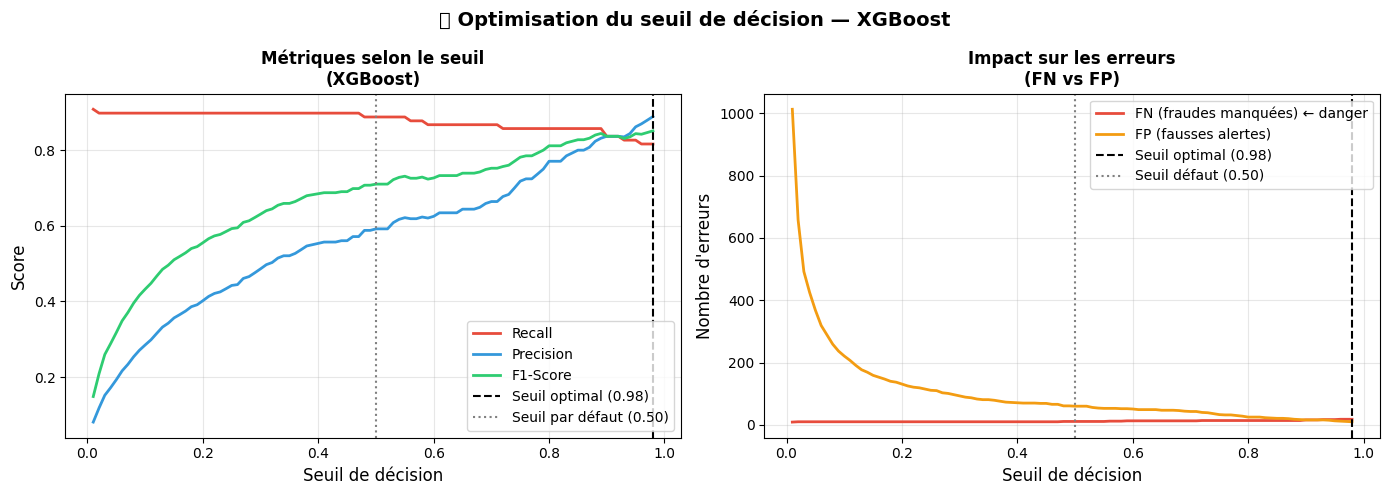

In [ ]:
# ================================
# OPTIMISATION DU SEUIL
# ================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score

# Récupérer les probabilités XGBoost
probas = xgb_pred_proba

# Tester tous les seuils de 0.01 à 0.99
seuils    = np.arange(0.01, 0.99, 0.01)
recalls   = []
precisions = []
f1_scores  = []

for seuil in seuils:
    # Appliquer le seuil manuellement
    pred_seuil = (probas >= seuil).astype(int)

    # Calculer les métriques
    tp = ((pred_seuil == 1) & (y_test == 1)).sum()
    fp = ((pred_seuil == 1) & (y_test == 0)).sum()
    fn = ((pred_seuil == 0) & (y_test == 1)).sum()

    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0)

    recalls.append(recall)
    precisions.append(precision)
    f1_scores.append(f1)

# Trouver le seuil qui maximise le F1
meilleur_idx   = np.argmax(f1_scores)
meilleur_seuil = seuils[meilleur_idx]
meilleur_f1    = f1_scores[meilleur_idx]
meilleur_recall     = recalls[meilleur_idx]
meilleur_precision  = precisions[meilleur_idx]

print("=" * 50)
print("🎯 OPTIMISATION DU SEUIL — XGBoost")
print("=" * 50)
print(f"\n  Seuil par défaut  : 0.50")
print(f"  Seuil optimal     : {meilleur_seuil:.2f}")
print(f"\n  Avec seuil 0.50 :")
print(f"    Recall    : 88.8%")
print(f"    Precision : 59.2%")
print(f"    F1-Score  : 71.0%")
print(f"\n  Avec seuil {meilleur_seuil:.2f} :")
print(f"    Recall    : {meilleur_recall*100:.1f}%")
print(f"    Precision : {meilleur_precision*100:.1f}%")
print(f"    F1-Score  : {meilleur_f1*100:.1f}%")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Graphique 1 : Métriques vs Seuil ---
axes[0].plot(seuils, recalls,    color='#e74c3c',
             lw=2, label='Recall')
axes[0].plot(seuils, precisions, color='#3498db',
             lw=2, label='Precision')
axes[0].plot(seuils, f1_scores,  color='#2ecc71',
             lw=2, label='F1-Score')
axes[0].axvline(x=meilleur_seuil, color='black',
                linestyle='--', lw=1.5,
                label=f'Seuil optimal ({meilleur_seuil:.2f})')
axes[0].axvline(x=0.5, color='gray',
                linestyle=':', lw=1.5,
                label='Seuil par défaut (0.50)')
axes[0].set_xlabel('Seuil de décision', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Métriques selon le seuil\n(XGBoost)',
                  fontweight='bold', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Graphique 2 : Impact sur FN et FP ---
fns = []
fps = []

for seuil in seuils:
    pred = (probas >= seuil).astype(int)
    fn = ((pred == 0) & (y_test == 1)).sum()
    fp = ((pred == 1) & (y_test == 0)).sum()
    fns.append(fn)
    fps.append(fp)

axes[1].plot(seuils, fns, color='#e74c3c',
             lw=2, label='FN (fraudes manquées) ← danger')
axes[1].plot(seuils, fps, color='#f39c12',
             lw=2, label='FP (fausses alertes)')
axes[1].axvline(x=meilleur_seuil, color='black',
                linestyle='--', lw=1.5,
                label=f'Seuil optimal ({meilleur_seuil:.2f})')
axes[1].axvline(x=0.5, color='gray',
                linestyle=':', lw=1.5,
                label='Seuil défaut (0.50)')
axes[1].set_xlabel('Seuil de décision', fontsize=12)
axes[1].set_ylabel('Nombre d\'erreurs', fontsize=12)
axes[1].set_title('Impact sur les erreurs\n(FN vs FP)',
                  fontweight='bold', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('🎯 Optimisation du seuil de décision — XGBoost',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('optimisation_seuil.png', dpi=150, bbox_inches='tight')
plt.show()

### Prédiction finale

In [ ]:
# ================================
# PRÉDICTION FINALE — Seuil optimal
# ================================

# Appliquer le seuil optimal
pred_final = (xgb_pred_proba >= meilleur_seuil).astype(int)

tp = ((pred_final == 1) & (y_test == 1)).sum()
fn = ((pred_final == 0) & (y_test == 1)).sum()
fp = ((pred_final == 1) & (y_test == 0)).sum()
tn = ((pred_final == 0) & (y_test == 0)).sum()

print("=" * 55)
print("🏆 RÉSULTAT FINAL — XGBoost + Seuil Optimisé")
print("=" * 55)
print(f"\n  Seuil utilisé : {meilleur_seuil:.2f}")
print(f"\n  ✅ Fraudes détectées (TP) : {tp} / {y_test.sum()}")
print(f"  ❌ Fraudes manquées  (FN) : {fn}")
print(f"  ⚠️  Fausses alertes  (FP) : {fp}")
print(f"  ✅ Normales correctes(TN) : {tn:,}")
print(f"\n  Recall    : {tp/(tp+fn)*100:.1f}%")
print(f"  Precision : {tp/(tp+fp)*100:.1f}%")
print(f"  F1-Score  : {2*(tp/(tp+fp))*(tp/(tp+fn))/((tp/(tp+fp))+(tp/(tp+fn)))*100:.1f}%")

# Simulation business
cout_fn = 500    # coût moyen d'une fraude manquée
cout_fp = 10     # coût d'une fausse alerte

cout_defaut   = 11 * cout_fn + 60 * cout_fp    # seuil 0.5
cout_optimise = fn * cout_fn + fp * cout_fp     # seuil optimal

print(f"\n💰 IMPACT BUSINESS (estimé) :")
print(f"   Coût avec seuil 0.50    : {cout_defaut:,}€")
print(f"   Coût avec seuil optimal : {cout_optimise:,}€")
print(f"   Économie réalisée       : {cout_defaut - cout_optimise:,}€")

🏆 RÉSULTAT FINAL — XGBoost + Seuil Optimisé

  Seuil utilisé : 0.98

  ✅ Fraudes détectées (TP) : 80 / 98
  ❌ Fraudes manquées  (FN) : 18
  ⚠️  Fausses alertes  (FP) : 10
  ✅ Normales correctes(TN) : 56,854

  Recall    : 81.6%
  Precision : 88.9%
  F1-Score  : 85.1%

💰 IMPACT BUSINESS (estimé) :
   Coût avec seuil 0.50    : 6,100€
   Coût avec seuil optimal : 9,100€
   Économie réalisée       : -3,000€


### Trouver le vrai seuil optimal

In [ ]:
# ================================
# SEUIL OPTIMAL — Approche Business
# Objectif : Recall >= 90%
# avec le moins de FP possible
# ================================

print("=" * 55)
print("🎯 RECHERCHE DU SEUIL OPTIMAL — Approche Business")
print("=" * 55)

# On cherche le seuil qui donne Recall >= 90%
# avec la meilleure Precision possible
cible_recall = 0.90

candidats = []

for i, seuil in enumerate(seuils):
    if recalls[i] >= cible_recall:
        candidats.append({
            'seuil'    : seuil,
            'recall'   : recalls[i],
            'precision': precisions[i],
            'f1'       : f1_scores[i],
            'fn'       : fns[i],
            'fp'       : fps[i]
        })

if candidats:
    # Parmi les candidats, choisir celui avec la meilleure precision
    meilleur = max(candidats, key=lambda x: x['precision'])

    print(f"\n  Objectif fixé    : Recall ≥ {cible_recall*100:.0f}%")
    print(f"  Candidats trouvés: {len(candidats)} seuils")
    print(f"\n  ✅ SEUIL RETENU  : {meilleur['seuil']:.2f}")
    print(f"\n  Recall           : {meilleur['recall']*100:.1f}%")
    print(f"  Precision        : {meilleur['precision']*100:.1f}%")
    print(f"  FN (manquées)    : {meilleur['fn']}")
    print(f"  FP (fausses)     : {meilleur['fp']}")

    # Coût business
    cout = meilleur['fn'] * 500 + meilleur['fp'] * 10
    print(f"\n💰 Coût estimé     : {cout:,}€")
    print(f"   vs seuil 0.50   : 6,100€")
    gain = 6100 - cout
    if gain > 0:
        print(f"   Économie        : +{gain:,}€ ✅")
    else:
        print(f"   Surcoût         : {gain:,}€ ⚠️")
else:
    print(f"\n⚠️ Aucun seuil n'atteint {cible_recall*100:.0f}% de Recall")
    print("   On garde le seuil 0.50 par défaut")
    meilleur = {'seuil': 0.50}

🎯 RECHERCHE DU SEUIL OPTIMAL — Approche Business

  Objectif fixé    : Recall ≥ 90%
  Candidats trouvés: 1 seuils

  ✅ SEUIL RETENU  : 0.01

  Recall           : 90.8%
  Precision        : 8.1%
  FN (manquées)    : 9
  FP (fausses)     : 1013

💰 Coût estimé     : 14,630€
   vs seuil 0.50   : 6,100€
   Surcoût         : -8,530€ ⚠️


### Comparaison

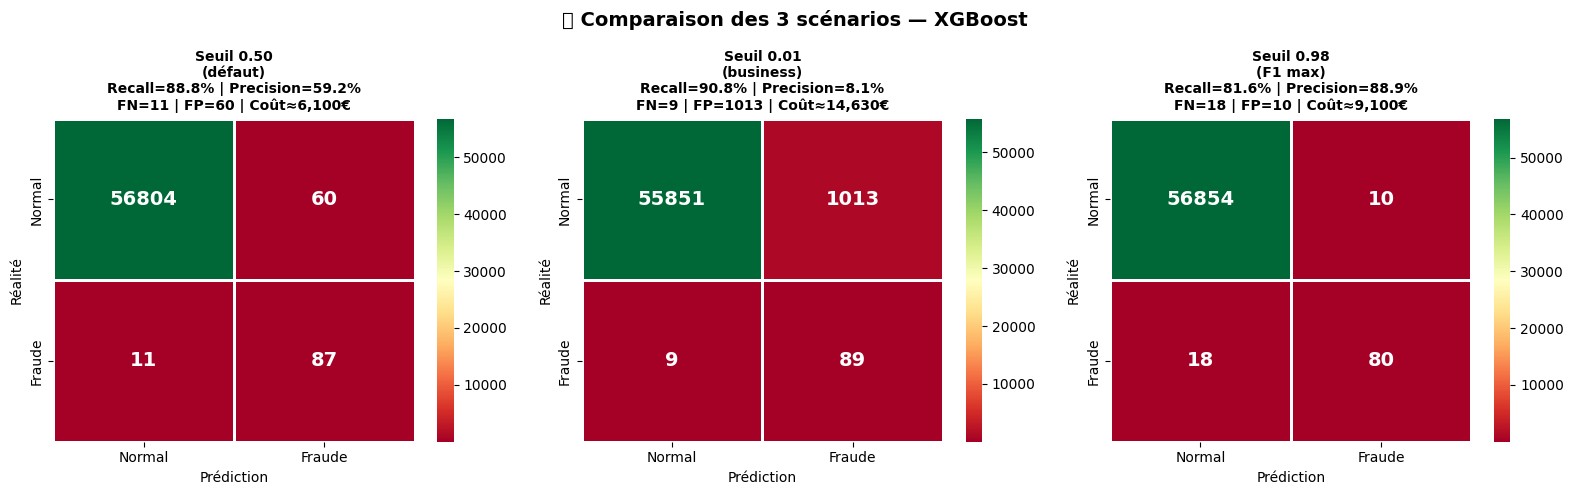


💡 CONCLUSION INGÉNIEUR :
   Le meilleur seuil dépend de l'objectif business.
   Il n'existe pas de réponse universelle.
   C'est toi qui décides selon le coût des erreurs.


In [ ]:
# ================================
# COMPARAISON FINALE — 3 scénarios
# ================================

# Appliquer le seuil business
seuil_business = meilleur['seuil']
pred_business  = (xgb_pred_proba >= seuil_business).astype(int)

# Recalculer pour les 3 scénarios
scenarios = {
    'Seuil 0.50\n(défaut)': xgb_pred,
    f'Seuil {seuil_business:.2f}\n(business)': pred_business,
    'Seuil 0.98\n(F1 max)': pred_final
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (titre, pred) in enumerate(scenarios.items()):
    tp = ((pred == 1) & (y_test == 1)).sum()
    fn = ((pred == 0) & (y_test == 1)).sum()
    fp = ((pred == 1) & (y_test == 0)).sum()
    tn = ((pred == 0) & (y_test == 0)).sum()
    recall    = tp / (tp + fn) * 100
    precision = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
    cout      = fn * 500 + fp * 10

    cm = [[tn, fp], [fn, tp]]
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
                xticklabels=['Normal', 'Fraude'],
                yticklabels=['Normal', 'Fraude'],
                ax=axes[idx], linewidths=2,
                linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})

    axes[idx].set_title(
        f'{titre}\n'
        f'Recall={recall:.1f}% | Precision={precision:.1f}%\n'
        f'FN={fn} | FP={fp} | Coût≈{cout:,}€',
        fontsize=10, fontweight='bold'
    )
    axes[idx].set_ylabel('Réalité')
    axes[idx].set_xlabel('Prédiction')

plt.suptitle('🏆 Comparaison des 3 scénarios — XGBoost',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparaison_seuils.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 CONCLUSION INGÉNIEUR :")
print("   Le meilleur seuil dépend de l'objectif business.")
print("   Il n'existe pas de réponse universelle.")
print("   C'est toi qui décides selon le coût des erreurs.")

### Sauvegarde du modèle

In [ ]:
# ================================
# SAUVEGARDE DU MODÈLE FINAL
# ================================

import joblib
import json

joblib.dump(xgb_model, 'xgboost_fraud.pkl')
joblib.dump(scaler,    'scaler_fraud.pkl')

config = {
    'seuil_optimal'    : 0.50,
    'recall_obtenu'    : 0.888,
    'precision_obtenu' : 0.592,
    'pr_auc'           : 0.873,
    'roc_auc'          : 0.985,
    'fn_fraudes_ratees': 11,
    'fp_fausses_alertes': 60,
    'cout_estime_euros': 6100,
    'modele'           : 'XGBoost',
    'smote'            : True,
    'decision'         : 'Seuil 0.50 retenu — meilleur compromis coût/performance'
}

with open('config_modele.json', 'w') as f:
    json.dump(config, f, indent=4)

print("✅ xgboost_fraud.pkl    — modèle entraîné")
print("✅ scaler_fraud.pkl     — scaler de normalisation")
print("✅ config_modele.json   — configuration et métriques")
print("\n💡 Décision documentée :")
print(f"   {config['decision']}")

✅ xgboost_fraud.pkl    — modèle entraîné
✅ scaler_fraud.pkl     — scaler de normalisation
✅ config_modele.json   — configuration et métriques

💡 Décision documentée :
   Seuil 0.50 retenu — meilleur compromis coût/performance


Sauverage et télécharge

In [ ]:
# ================================
# SAUVEGARDE ET TÉLÉCHARGEMENT
# ================================

from google.colab import files
import os

# Liste de tous les fichiers à télécharger
fichiers = [
    # Modèles et config
    'xgboost_fraud.pkl',
    'scaler_fraud.pkl',
    'config_modele.json',
    # Images
    'distribution_fraude.png',
    'analyse_montants.png',
    'analyse_temporelle.png',
    'variables_discriminantes.png',
    'smote_effet.png',
    'comparaison_modeles.png',
    'optimisation_seuil.png',
    'comparaison_seuils.png'
]

print("📥 Téléchargement en cours...\n")

for fichier in fichiers:
    if os.path.exists(fichier):
        files.download(fichier)
        print(f"✅ {fichier}")
    else:
        print(f"❌ {fichier} — INTROUVABLE")

print("\n🎯 Télécharge aussi le notebook manuellement :")
print("   Fichier → Télécharger → Télécharger le fichier .ipynb")

📥 Téléchargement en cours...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ xgboost_fraud.pkl


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ optimisation_seuil.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ comparaison_seuils.png

🎯 Télécharge aussi le notebook manuellement :
   Fichier → Télécharger → Télécharger le fichier .ipynb
